# MFAA Chapter 16 Laboratory
**Malliavin Sensitivity Engine** (book §16.8)

A sensitivity layer over every engine: Greeks with error bars, estimator diagnostics, and the hedging projection. Seed `20261600`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch16
from dataclasses import replace

## 1. Malliavin weights match Black-Scholes
Integer-by-parts estimators for delta and vega.

In [2]:
p = ch16.MalliavinParams()
md_ = ch16.malliavin_delta(p); mv = ch16.malliavin_vega(p)
print(f"delta: weight {md_['estimate']:.4f} ± {md_['se']:.4f} vs BS {md_['closed_form']:.4f}")
print(f"vega:  weight {mv['estimate']:.2f} ± {mv['se']:.2f} vs BS {mv['closed_form']:.2f}")

delta: weight 0.5971 ± 0.0044 vs BS 0.5987
vega:  weight 38.13 ± 0.82 vs BS 38.67


## 2. RMSE-versus-N laws (Proposition 16.2)
The weight estimator scales as N^{-1/2}.

fitted slope -0.549


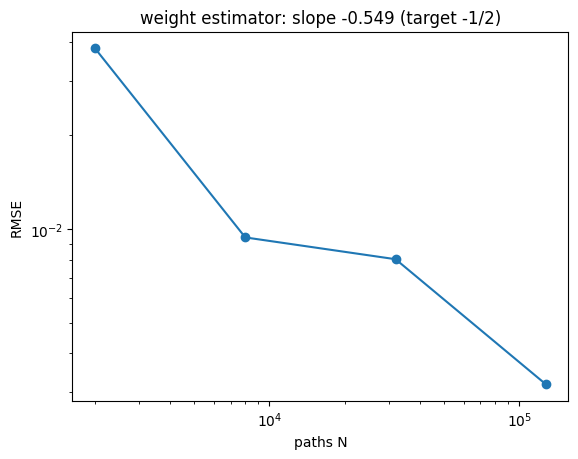

In [3]:
rw = ch16.rmse_scaling(p, 'weight')
plt.loglog(rw['Ns'], rw['rmses'], 'o-')
plt.xlabel('paths N'); plt.ylabel('RMSE'); plt.title(f"weight estimator: slope {rw['fitted_slope']:.3f} (target -1/2)")
print(f"fitted slope {rw['fitted_slope']:.3f}")

## 3. Ex 16.12 — Clark-Ocone hedging
Floor 0.0992; residual variance rises as rebalancing coarsens (weekly < monthly < quarterly).

In [4]:
for rebal in ('weekly','monthly','quarterly'):
    h = ch16.hedging_projection(replace(p, M=40000), rebal)
    print(f"{rebal}: floor {h['floor']:.4f}, realized residual var {h['realized_residual_var']:.4f}")

weekly: floor 0.0994, realized residual var 0.1025


monthly: floor 0.0994, realized residual var 0.1096


quarterly: floor 0.0994, realized residual var 0.1263


## 4. Validation checks

In [5]:
v = ch16.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_delta_weight PASS
V2_vega_weight PASS
V3_rmse_weight PASS
V4_hedging PASS
V5_envelope PASS
V6_reproducible PASS
ALL: True
